In [2]:
import pandas as pd
print(pd.__version__)

2.3.3


In [3]:
import pandas as pd
import sqlite3

df = pd.read_csv('../data/OnlineRetail.csv', encoding='unicode_escape')
conn = sqlite3.connect('../logistics.db')

df.to_sql('sales', conn, if_exists='replace', index=False)

query = """--sql
SELECT 
    StockCode, 
    MAX(Description) AS Description, 
    Count(StockCode) AS OrderCount,
    SUM(Quantity) AS NetVolume, 
    SUM(Quantity * UnitPrice) AS NetRevenue
FROM sales
WHERE CustomerID IS NOT NULL AND Description IS NOT NULL
GROUP BY StockCode
ORDER BY NetRevenue DESC
"""

result = pd.read_sql_query(query, conn)

result.head(10)

,StockCode,Description,OrderCount,NetVolume,NetRevenue
0,22423,REGENCY CAKESTAND 3 TIER,1905,11555,132870.40
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2077,34204,93979.20
2,85099B,JUMBO BAG RED RETROSPOT,1662,45066,83236.76
3,47566,PARTY BUNTING,1416,15027,67687.53
4,POST,POSTAGE,1196,3002,66710.24
5,84879,ASSORTED COLOUR BIRD ORNAMENT,1418,35314,56499.22
6,23084,RABBIT NIGHT LIGHT,857,27094,51137.80
7,22502,PICNIC BASKET WICKER SMALL,248,1413,46980.95
8,79321,CHILLI LIGHTS,530,9570,45936.81
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,1029,15164,41500.48


In [4]:
# 반품액이 더 커서 마이서스가 난 상품 제외
# 필터링 한 데이터에 새로운 컬럼을 만들 때, 원본을 건드는지 복사본을 건드리는지 헷갈리기 때문에 copy로 복사본 처리?
result = result[result["NetRevenue"] > 0].copy()

# 전체 매출 대비 비중 구하기
result["RevenueShare"] = result["NetRevenue"] / result['NetRevenue'].sum()

# cumsum()을 활용해서 누적 합계 구하기
result["CumShare"] = result["RevenueShare"].cumsum()

# 누적 합계 비율 별 등급 산출하기 ~70% - A, 70~90% - B, 90%~ - C    
result["Grade"] = pd.cut(result["CumShare"], [0, 0.7, 0.9, 1], labels=["A","B","C"], include_lowest=True)

# A등급의 수와 전체에서의 C등급의 비율 구하기
GradeACount = result["Grade"].value_counts()["A"]
GradeCPercentage = result["Grade"].value_counts()["C"] / result["Grade"].count()

print(GradeACount, GradeCPercentage)

grade_ratios = result["Grade"].value_counts(normalize=True)
print(grade_ratios)
print(grade_ratios * 100)

535 0.650288223991216
Grade
C    0.650288
B    0.202855
A    0.146857
Name: proportion, dtype: float64
Grade
C    65.028822
B    20.285479
A    14.685699
Name: proportion, dtype: float64


A등급 상품(전체 상품의 약 15%, 535개 상품)이 전체 매출의 70%를 차지함
C등급 상품(전체 상품의 약 65%, 2369개 상품)이 매출의 10%를 차지함

In [5]:
# 상위 10개의 상품의 전체 매출의 8% 이상을 차지하고 있음

# 등급별 합계/평균 요약해보기
summary = result.groupby('Grade').agg(
    TotalRevenue = ('NetRevenue', 'sum'),
    AvgRevenue = ('NetRevenue', 'mean'),
    TotalVolume = ('NetVolume', 'sum'),
    ProductCount = ('StockCode', 'count')
)

print(summary["TotalRevenue"]["A"] / summary["TotalRevenue"].sum())
print(summary)

0.6997080766814343
       TotalRevenue    AvgRevenue  TotalVolume  ProductCount
Grade                                                       
A       5858312.620  10950.117047      2711712           535
B       1675915.920   2267.815859      1283886           739
C        838281.104    353.854413       909417          2369


/var/folders/w9/pdz080nj1818r8kdjczn252c0000gn/T/ipykernel_90948/286885500.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = result.groupby('Grade').agg(


In [6]:
# A등급 물품들만 필터링하기
a_list = result[result["Grade"] == "A"].copy()

# 필터링 한 리스트에서 필요한 칼럼들을 뽑아 엑셀로 만들기
a_list_final = a_list[["StockCode", "Description", "NetVolume", "NetRevenue"]]
a_list_final.to_excel('../output/A_Grade_Product_List.xlsx', index=False)

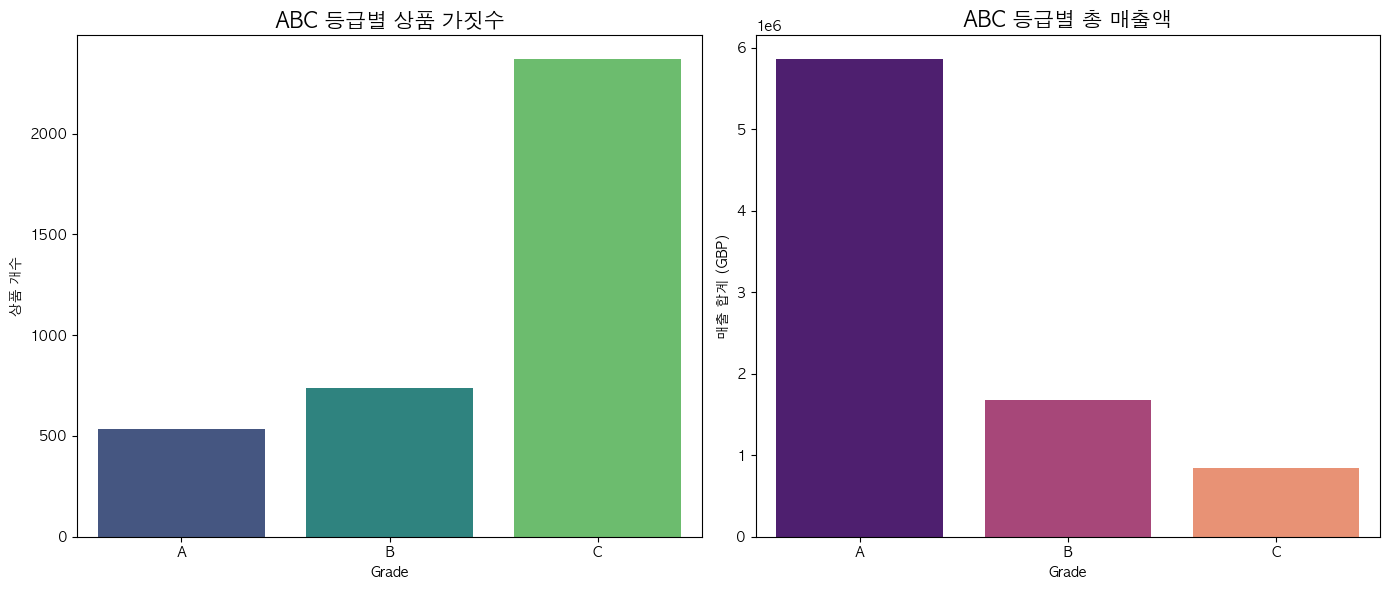

In [9]:
# 시각화 해보기
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=summary.index, y='ProductCount', data=summary, ax=ax[0], palette='viridis', hue=summary.index, legend=False)
ax[0].set_title('ABC 등급별 상품 가짓수', fontsize=15)
ax[0].set_ylabel('상품 개수')

sns.barplot(x=summary.index, y='TotalRevenue', data=summary, ax=ax[1], palette='magma', hue=summary.index, legend=False)
ax[1].set_title('ABC 등급별 총 매출액', fontsize=15)
ax[1].set_ylabel('매출 합계 (GBP)')

plt.tight_layout()
plt.savefig('../output/abc_analysis_visual.png')
plt.show()

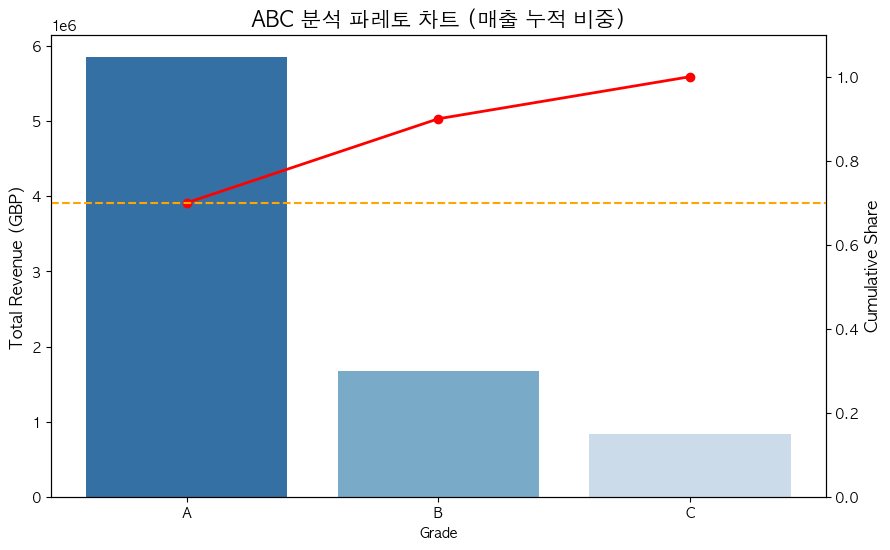

In [ ]:
import matplotlib.pyplot as plt

summary['CumShare'] = (summary['TotalRevenue'] / summary['TotalRevenue'].sum()).cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(x=summary.index, y='TotalRevenue', data=summary, ax=ax1, palette='Blues_r', hue=summary.index, legend=False)
ax1.set_ylabel('Total Revenue (GBP)', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(summary.index, summary['CumShare'], color='red', marker='o', linestyle='-', linewidth=2)
ax2.set_ylabel('Cumulative Share', fontsize=12)
ax2.set_ylim(0, 1.1) 

ax2.axhline(y=0.7, color='orange', linestyle='--', label='70% Threshold')

plt.title('ABC 분석 파레토 차트 (매출 누적 비중)', fontsize=15)
plt.savefig('../output/pareto_chart.png')
plt.show()

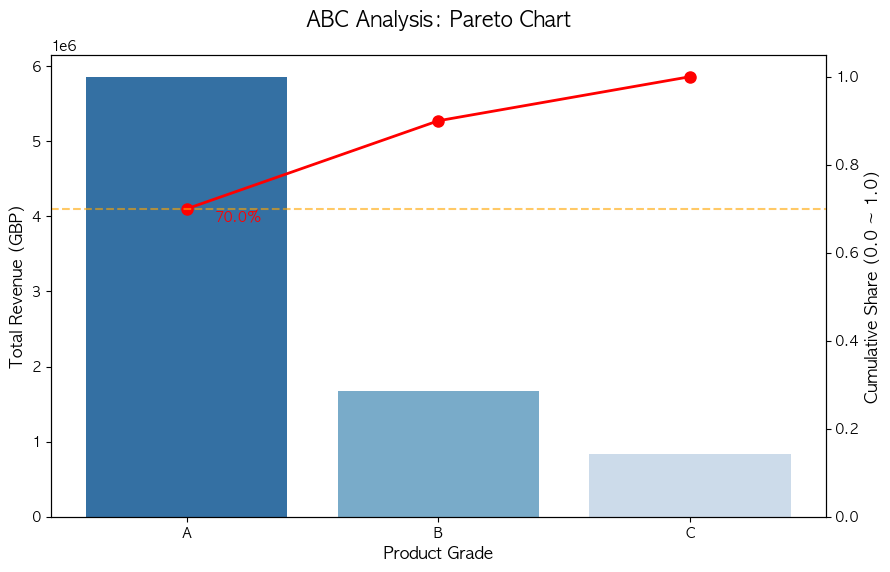

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(x=summary.index, y='TotalRevenue', data=summary, ax=ax1, 
            palette='Blues_r', hue=summary.index, legend=False)
ax1.set_ylabel('Total Revenue (GBP)', fontsize=12)
ax1.set_xlabel('Product Grade', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(summary.index, summary['CumShare'], color='red', marker='o', 
         markersize=8, linestyle='-', linewidth=2, label='Cumulative %')

ax2.axhline(y=0.7, color='orange', linestyle='--', alpha=0.6)
ax2.set_ylabel('Cumulative Share (0.0 ~ 1.0)', fontsize=12)
ax2.set_ylim(0, 1.05) 

a_val = summary.loc['A', 'CumShare']
ax2.annotate(f'{a_val:.1%}', xy=('A', a_val), xytext=(20, -10), 
             textcoords='offset points', color='red', fontweight='bold')

plt.title('ABC Analysis: Pareto Chart', fontsize=15, pad=20)
plt.savefig('../output/pareto_chart_fixed.png')
plt.show()